In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
def f(x):
    return 3*x**2 - 4 * x + 5

In [7]:
f(3.0)

20.0

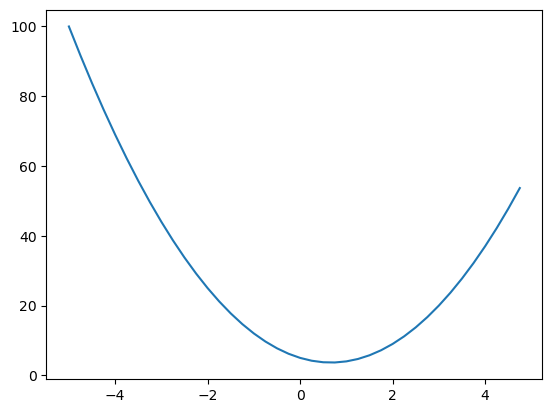

In [8]:
xs = np.arange(-5,5 , 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [9]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))


2.999378523327323e-12

In [10]:
a = 2.0
b = -3.0
c = 10.0
d = a * b +c
print(d)


4.0


In [11]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d1 = a * b +c

c += h
d2 = a*b +c
print("d1", d1)
print("d2",d2)
print("slope", (d2-d1)/h)



d1 4.0
d2 4.0001
slope 0.9999999999976694


In [53]:
class Value:
    def __init__(self, value, _children = (), _op = "", label = ''):
        self.data = value
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, {self, other}, "+")
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, {self, other}, "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
        
    def __rmul__(self, other):
        return self* other
        
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data **other , (self,), f'**{other}')
        def _backward():
            self.grad += (other)*self.data**(other - 1) * out.grad 
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + (-other)
        
    def __truediv__(self , other):
        return self * other**-1
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2* x) - 1)/ (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad = (1- t**2)* out.grad
        out._backward = _backward
        return out

    def __rsub__(self, other): # other - self
        return Value(other) + (-self)

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [13]:
a = Value(2)
a-1

Value(data=1)

In [44]:
from graphviz import Digraph 
def trace(root):
    #bulids a set of all nodes and edges in a graph
    nodes,edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr = {'rankdir': 'LR'}) # LR = Left to Right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f  | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name= uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

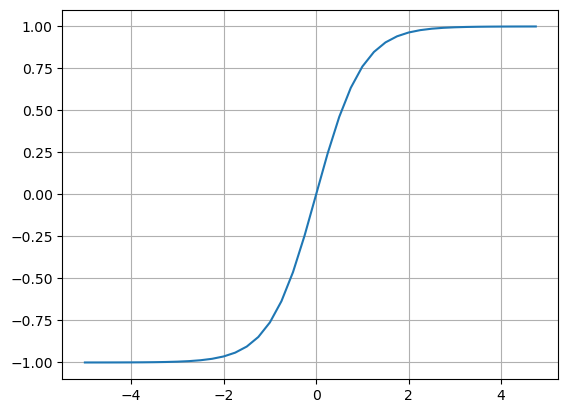

In [15]:
plt.plot(np.arange(-5,5 ,0.25), np.tanh(np.arange(-5,5, 0.25)))
plt.grid()

In [16]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

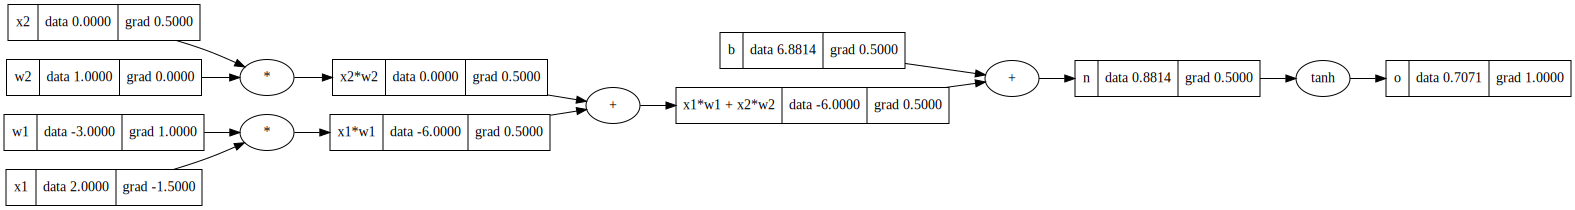

In [17]:
draw_dot(o)

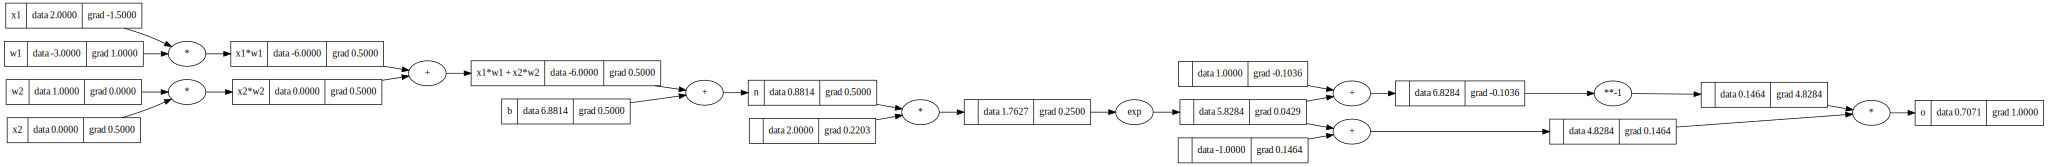

In [18]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2* n).exp()
o = (e - 1)/ (e + 1); o.label = 'o'

o.backward()

draw_dot(o)

In [19]:
import torch


In [20]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print('x2',x2.grad.item())
print('x1', x1.grad.item())
print('w1',w1.grad.item())
print('w2', w2.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
x1 -1.5000003851533106
w1 1.0000002567688737
w2 0.0


In [21]:
x1.data


tensor([2.], dtype=torch.float64)

In [63]:
import random
class Neuron:
    def __init__(self, nin): # nin = number of inputs
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act =self.b 
        for wi, xi in zip(self.w, x):
            act = act + (wi * xi)
        out = act.tanh()
        return out
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for n in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

class MLP:
    def __init__(self, nin, nouts): # outs = list of nodes we want to be as output as each layer
        size = [nin] + nouts
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layers in self.layers:
            x = layers(x)
        return x
        
x = [2.0, 3,0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
        

Value(data=-0.6861737397560822)

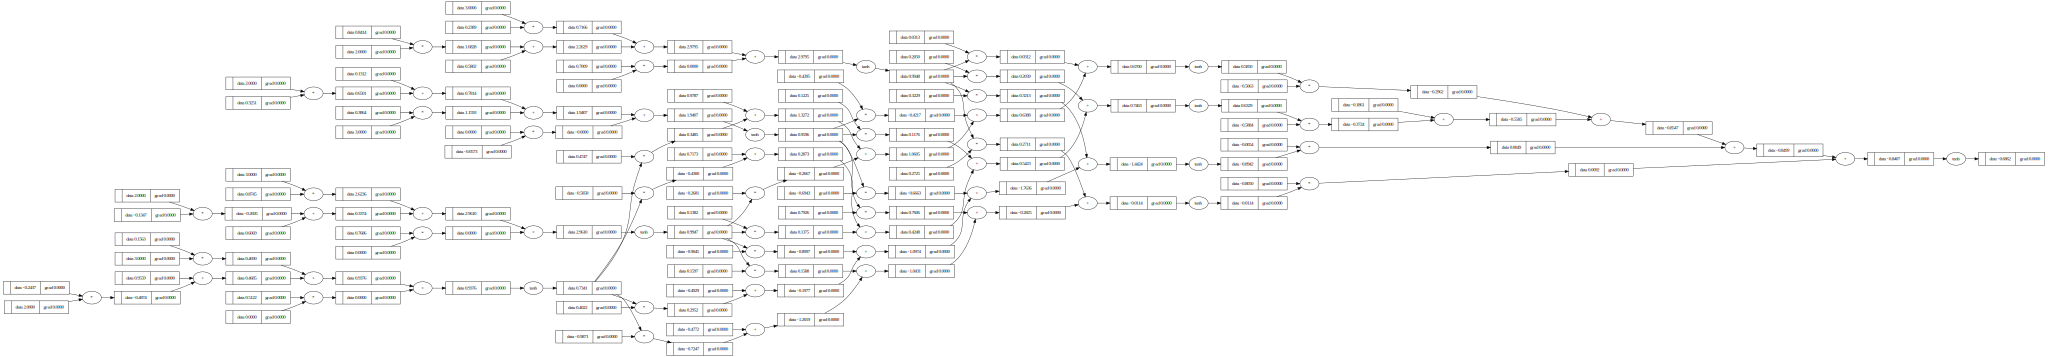

In [64]:
draw_dot(n(x))

In [78]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [ 1.0, -1.0, -1.0, 1.0] # expected outputs

y_pred = [n(x) for x in xs]
y_pred

[Value(data=-0.799264179558316),
 Value(data=-0.7050681924852871),
 Value(data=-0.4470505152714384),
 Value(data=-0.7270468399281427)]

In [90]:
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, y_pred)), Value(0))
loss

Value(data=6.612780278892921)

In [91]:
loss.backward()

In [93]:
n.layers[0].neurons[0].w[0].grad

-1.936133004033596

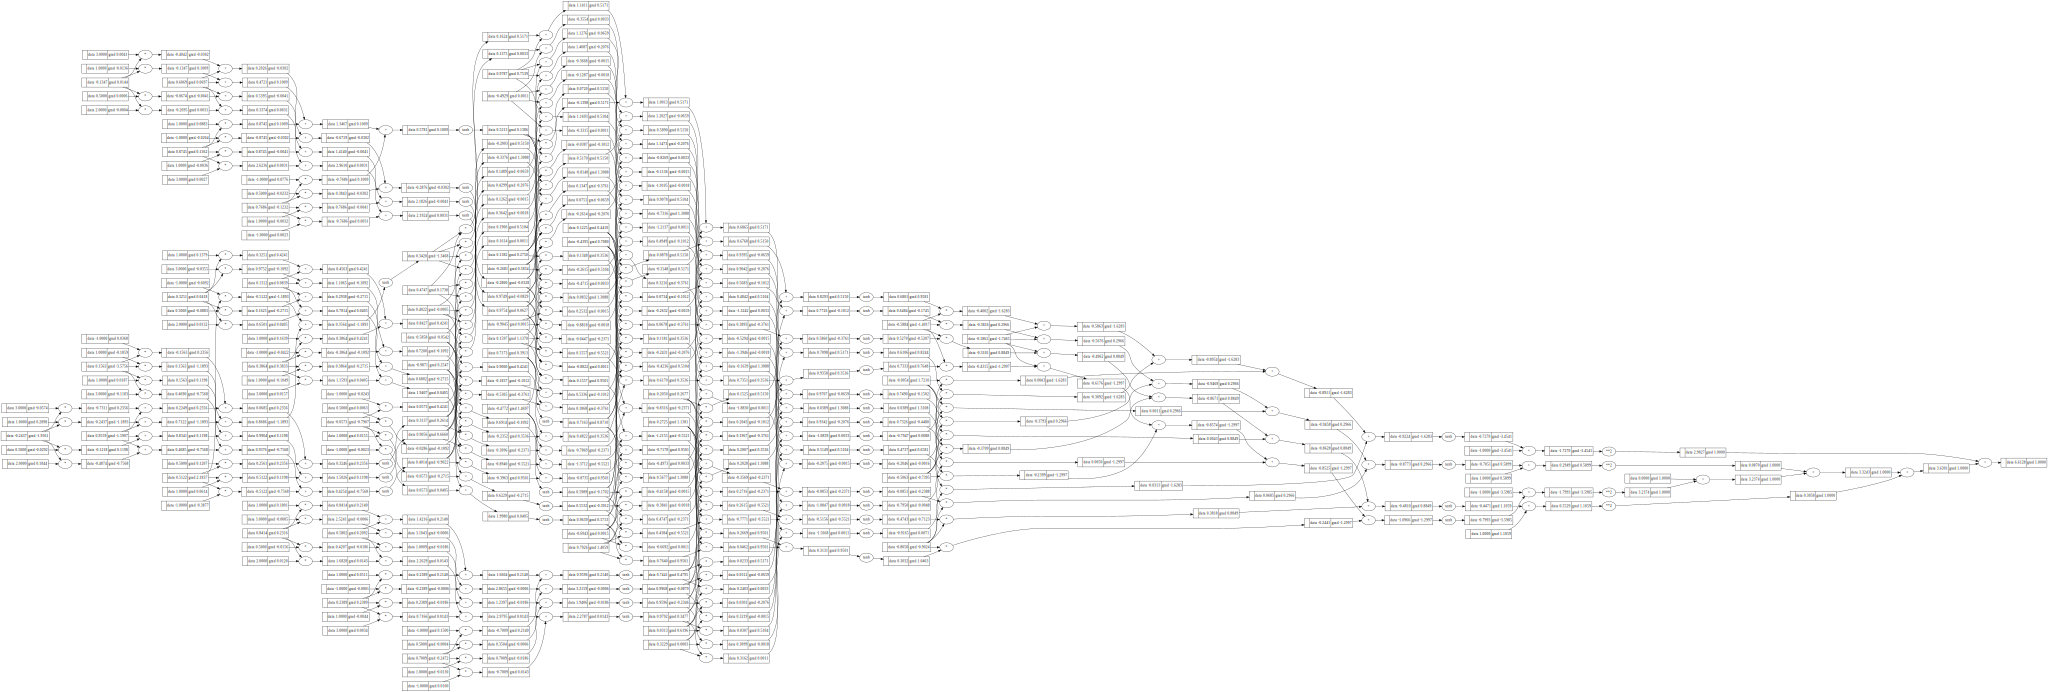

In [94]:
draw_dot(loss)